In [ ]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)


import shutil
shutil.move(path, './data/emnist')

Resuming download from 298844160 bytes (1031339304 bytes left)...
Resuming download to /Users/antonioponti/.cache/kagglehub/datasets/crawford/emnist/3.archive (298844160/1330183464) bytes left.


100%|██████████| 1.24G/1.24G [01:31<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: /Users/antonioponti/.cache/kagglehub/datasets/crawford/emnist/versions/3


'./data/emnist'

In [33]:
import tensorflow as tf
import keras.backend as K
from keras.backend import clear_session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential, load_model
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import layers
from keras.layers import *
from keras.utils import to_categorical

## Optical Character Recognition (OCR)

Let's tackle a task of OCR using emnist dataset to train a ```CONV-LSTM``` model to recognize a set off characters from images.

In [23]:
train_df = pd.read_csv("data/emnist/emnist_train.csv")

In [24]:
label_dict = {0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9',
 10: 'A',
 11: 'B',
 12: 'C',
 13: 'D',
 14: 'E',
 15: 'F',
 16: 'G',
 17: 'H',
 18: 'I',
 19: 'J',
 20: 'K',
 21: 'L',
 22: 'M',
 23: 'N',
 24: 'O',
 25: 'P',
 26: 'Q',
 27: 'R',
 28: 'S',
 29: 'T',
 30: 'U',
 31: 'V',
 32: 'W',
 33: 'X',
 34: 'Y',
 35: 'Z',
 36: 'a',
 37: 'b',
 38: 'd',
 39: 'e',
 40: 'f',
 41: 'g',
 42: 'h',
 43: 'n',
 44: 'q',
 45: 'r',
 46: 't'
}

## Preprocessing

In [ ]:
W, H = 28, 28
X = train_df.iloc[:,2:]

In [26]:
def reshape_and_rotate(image):
    W = 28
    H = 28
    image = image.reshape(W, H)
    image = np.fliplr(image)
    image = np.rot90(image)
    return image

In [28]:
X = np.apply_along_axis(reshape_and_rotate, 1, X.values.astype('float32'))
X = X / 255

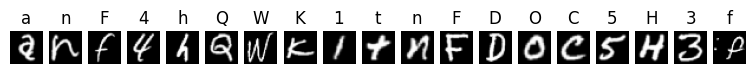

In [ ]:
# Data visualization
plt.figure(figsize=(10,10))
for i in range(1,20):
    plt.subplot(1,20,i)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.gray)
    plt.title(train_df.iloc[i]['char'])
    plt.axis('off')

In [30]:
X.shape

(112800, 28, 28)

In [31]:
X = X.reshape(-1, W, H, 1)
X.shape

(112800, 28, 28, 1)

In [32]:
y = train_df.iloc[:,1].values
number_of_classes = len(set(y))
y = to_categorical(y, number_of_classes)

In [38]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size= 0.1, random_state=1)

## Model

In [ ]:
model = Sequential() 
model.add(layers.Conv2D(16, (3,3), activation = 'relu', padding='same',input_shape=(W, H, 1)))
model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
#
model.add(layers.Conv2D(32, (3,3), activation = 'relu', padding='same'))
model.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))
model.add(layers.BatchNormalization())
#
model.add(layers.Reshape(target_shape=((1, 1568)), name='reshape'))
#
model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout = 0.2)))
model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout = 0.2)))
#
model.add(layers.Flatten())
#
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(number_of_classes, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1568)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1, 256)         │     1,737,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,175,855 (8.30 MB)

 Trainable params: 2,175,791 (8.30 MB)

 Non-trainable params: 64 (256.00 B)

In [40]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min')

### Training

In [41]:
history = model.fit(X_train,
                    y_train, 
                    epochs=30, 
                    batch_size=64, 
                    verbose=1, 
                    validation_split=0.1,
                    callbacks=[early_stopping])

Epoch 1/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.7793 - loss: 0.6919 - val_accuracy: 0.8496 - val_loss: 0.4311
Epoch 2/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8546 - loss: 0.4085 - val_accuracy: 0.8623 - val_loss: 0.3997
Epoch 3/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8699 - loss: 0.3543 - val_accuracy: 0.8630 - val_loss: 0.4033
Epoch 4/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8794 - loss: 0.3216 - val_accuracy: 0.8726 - val_loss: 0.3655
Epoch 5/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8870 - loss: 0.3001 - val_accuracy: 0.8746 - val_loss: 0.3542
Epoch 6/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.8915 - loss: 0.2826 - val_accuracy: 0.8667 - val_loss: 0.3803
Epoch 7/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.8969 - loss: 0.2654 - val_accuracy: 0.8771 - val_loss: 0.3600
Epoch 8/30
1428/1428 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9004 -

### Evaluation

In [43]:
test_df = pd.read_csv('data/emnist/emnist_test.csv')
X_test = test_df.iloc[:,2:]
X_test = np.apply_along_axis(reshape_and_rotate, 1, X_test.values.astype('float32'))
X_test = X_test / 255
X_test = X_test.reshape(-1, W, H, 1)


y_test = test_df.iloc[:,1].values
number_of_classes = len(set(y_test))
y_test = to_categorical(y_test, number_of_classes)

In [44]:
model.evaluate(X_test,y_test)

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8749 - loss: 0.3784


[0.3784436881542206, 0.8749468326568604]

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


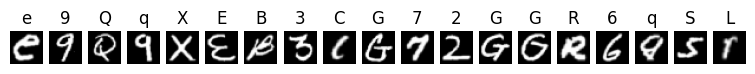

In [45]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10,10))
for i in range(1,20):
    plt.subplot(1,20,i)
    plt.imshow(X_test[i].reshape(28, 28), cmap=plt.cm.gray)
    plt.title(label_dict[y_pred[i].argmax()])
    plt.axis('off')